# Capstone project - Air passengers, start to finish

The course pipeline, on this series: explore it, decompose it, set the
benchmark floor, check what the floor leaves on the table, fit a model
through the framework, cross-validate, and read the result against the
floor.

**What is graded is the process, not the number.** A low MASE from one
holdout with no intervals scores worse than an honest analysis that
concludes the benchmark wins.

Full rules and report requirements: `brief.md`. Grading: `rubric.md`. This
notebook is the first deliverable; it should run top to bottom in under ten
minutes on Colab.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/SDAIAAcademy/international-airpassengers-project.git /content/proj
    %cd /content/proj
    !pip install -q -e .

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coursekit import plotting as P
from coursekit import scoring

P.use_course_style()

SEASON_LENGTH = 12
H = 12            # forecast horizon for cross-validation
H_REPORT = 24     # forecast horizon for the report

---
# 0. The data

Monthly international air passenger numbers, 1949-01 to 1960-12: 144
observations, no gaps. The Box & Jenkins classic (1970) — twelve years of
growth, and a year that does not repeat the same way twice.

Fetched from statsmodels' R-datasets on first run; no download step.

In [2]:
from statsmodels.datasets import get_rdataset

raw = get_rdataset("AirPassengers").data
t = raw["time"].astype(float).to_numpy()
years = np.floor(t).astype(int)
months = np.clip(np.round((t - years) * 12).astype(int) + 1, 1, 12)
df = pd.DataFrame({
    "unique_id": "Air passengers (Box & Jenkins)",
    "ds": pd.to_datetime(pd.Series(years).astype(str) + "-" +
                         pd.Series(months).astype(str).str.zfill(2) + "-01"),
    "y": raw["value"].astype(float),
}).sort_values("ds").reset_index(drop=True)
df.head()

,unique_id,ds,y
0,Air passengers (Box & Jenkins),1949-01-01,112.0
1,Air passengers (Box & Jenkins),1949-02-01,118.0
2,Air passengers (Box & Jenkins),1949-03-01,132.0
3,Air passengers (Box & Jenkins),1949-04-01,129.0
4,Air passengers (Box & Jenkins),1949-05-01,121.0


In [3]:
# Confirm the calendar: 144 months, monthly from 1949-01 to 1960-12, no gaps.
n_obs = len(df)
range_ = (df["ds"].min(), df["ds"].max())
full_index = pd.date_range(range_[0], range_[1], freq="MS")
n_gaps = len(set(full_index) - set(df["ds"]))
print(f"{n_obs} months, {range_[0].date()} to {range_[1].date()}, {n_gaps} gaps")


144 months, 1949-01-01 to 1960-12-01, 0 gaps


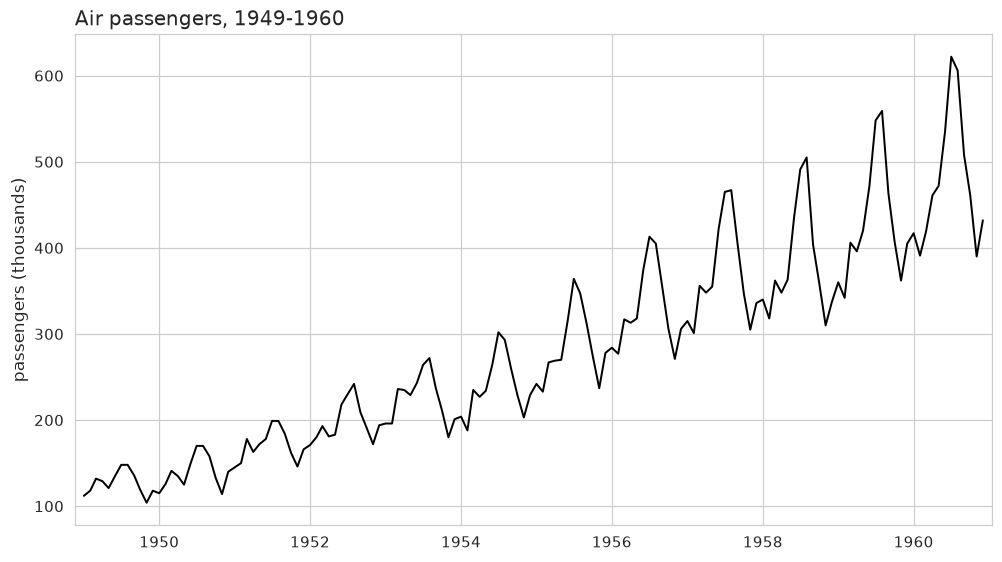

In [4]:
P.plot_series(df, title="Air passengers, 1949-1960",
              ylabel="passengers (thousands)", xlabel="")
plt.show()

**First read.** Before any model, write two sentences that describe this
series in plain language - the kind a non-forecaster could repeat. (Trend?
Seasonality? What happens to the swings as the level grows? Cycle?) These two
sentences belong at the top of your report.

---

**Answer.** The series is twelve years of monthly international air-passenger counts, 1949 to 1960, rising every year with no gaps. The level grows roughly exponentially and the size of the yearly swing grows with the level, so the amplitude of the seasonality is multiplicative, not additive. There is a clear annual cycle peaking in the northern-hemisphere summer and a small, non-repeating residual cycle around the trend.


---
# 1. Exploration and shape

The Day 1 toolkit, in order. Every chart should carry its claim: a title that
says what it shows, not just "series".

**1.1 Decompose.** STL, additive, period 12. Read all three panels: which
component does the work, and what does the remainder look like?

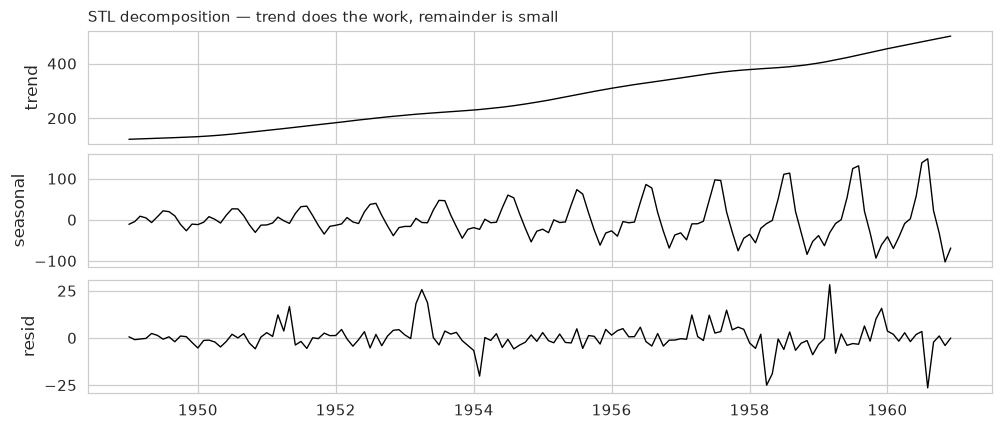

In [5]:
from statsmodels.tsa.seasonal import STL

# STL decomposition, additive, period 12. The brief asks for additive here;
# the strengths computed next quantify how much each component carries.
stl = STL(df["y"], period=12, robust=True)
dcmp = stl.fit()

# coursekit.decomposition_plot wants a frame with a 'ds' column and one
# column per component, so we assemble it by hand.
stl_df = pd.DataFrame({
    "ds": df["ds"],
    "trend": dcmp.trend,
    "seasonal": dcmp.seasonal,
    "resid": dcmp.resid,
})

P.decomposition_plot(
    stl_df, cols=["trend", "seasonal", "resid"],
    title="STL decomposition — trend does the work, remainder is small",
    x="ds")
plt.show()


**1.2 Trend and seasonal strength.** The two numbers from Day 1, computed
the same way (textbook formulas on the STL components). State what they
imply for model choice.

In [6]:
# Textbook strength formulas on the STL components (Hyndman & Athanasopoulos):
#   F_T = max(0, 1 - Var(R) / Var(T + R))
#   F_S = max(0, 1 - Var(R) / Var(S + R))
trend = dcmp.trend
seasonal = dcmp.seasonal
resid = dcmp.resid
trend_strength = max(0.0, 1 - np.var(resid) / np.var(trend + resid))
seasonal_strength = max(0.0, 1 - np.var(resid) / np.var(seasonal + resid))
print(f"trend strength: {trend_strength:.2f}")
print(f"seasonal strength: {seasonal_strength:.2f}")


trend strength: 1.00
seasonal strength: 0.98


**1.3 Autocorrelation.** The ACF of the raw series. What is at lag 12?
At 24? What does that tell you before you fit anything?

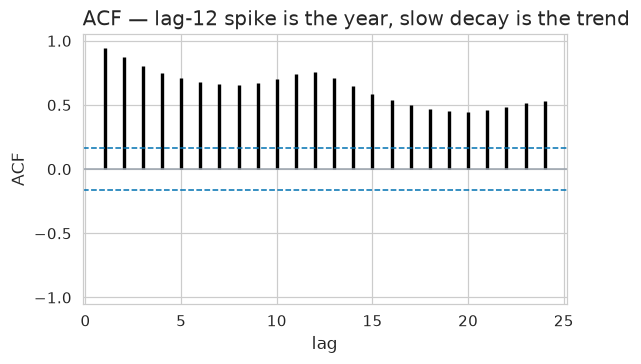

In [7]:
# ACF of the raw series, 24 lags. The spikes at 12 and 24 are the yearly
# seasonality; the slow, near-linear decay from lag 1 is the trend.
P.acf_plot(df["y"], nlags=24,
           title="ACF — lag-12 spike is the year, slow decay is the trend")
plt.show()


---
# 2. The floor

The seasonal naive is the first model you fit on any series - not as a
formality, as the thing everything else has to beat. Fit it, check what it
leaves on the table, and give it an honest interval.

In [8]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, Naive

# Two benchmarks: the seasonal naive (the floor) and the non-seasonal naive.
# Naive ignores the annual pattern, so SeasonalNaive remains the floor to beat.
floor_sf = StatsForecast(models=[SeasonalNaive(season_length=SEASON_LENGTH), Naive()],
                         freq="MS", n_jobs=1)
floor_fc = floor_sf.forecast(df=df, h=H_REPORT, level=scoring.LEVELS)
floor_fc.head()


,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,...,Naive-lo-20,Naive-lo-40,Naive-lo-60,Naive-lo-80,Naive-lo-95,Naive-hi-20,Naive-hi-40,Naive-hi-60,Naive-hi-80,Naive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,417.0,407.799511,397.956005,386.435898,370.4595,345.822448,426.200489,436.043995,...,423.459566,414.322245,403.628605,388.798374,365.928814,440.540434,449.677755,460.371395,475.201626,498.071186
1,Air passengers (Box & Jenkins),1961-02-01,391.0,381.799511,371.956005,360.435898,344.4595,319.822448,400.200489,410.043995,...,419.922002,406.999879,391.876788,370.903674,338.561233,444.077998,457.000121,472.123212,493.096326,525.438767
2,Air passengers (Box & Jenkins),1961-03-01,419.0,409.799511,399.956005,388.435898,372.4595,347.822448,428.200489,438.043995,...,417.207534,401.381230,382.859302,357.172589,317.561350,446.792466,462.618770,481.140698,506.827411,546.438650
3,Air passengers (Box & Jenkins),1961-04-01,461.0,451.799511,441.956005,430.435898,414.4595,389.822448,470.200489,480.043995,...,414.919132,396.644490,375.257210,345.596748,299.857629,449.080868,467.355510,488.742790,518.403252,564.142371
4,Air passengers (Box & Jenkins),1961-05-01,472.0,462.799511,452.956005,441.435898,425.4595,400.822448,481.200489,491.043995,...,412.903009,392.471338,368.559632,335.398227,284.260338,451.096991,471.528662,495.440368,528.601773,579.739662


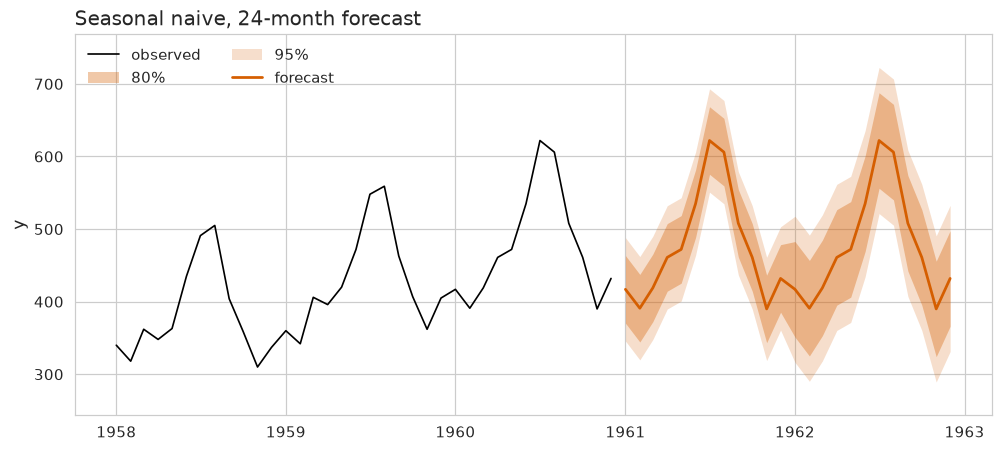

In [9]:
P.fan_chart(df, floor_fc.rename(columns={
            "SeasonalNaive": "mean",
            "SeasonalNaive-lo-20": "lo-20",
            "SeasonalNaive-lo-40": "lo-40",
            "SeasonalNaive-lo-60": "lo-60",
            "SeasonalNaive-lo-80": "lo-80",
            "SeasonalNaive-lo-95": "lo-95",
            "SeasonalNaive-hi-20": "hi-20",
            "SeasonalNaive-hi-40": "hi-40",
            "SeasonalNaive-hi-60": "hi-60",
            "SeasonalNaive-hi-80": "hi-80",
            "SeasonalNaive-hi-95": "hi-95",
            "ds": "ds"}),
            title="Seasonal naive, 24-month forecast",
            history_tail=36, levels=(80, 95))
plt.show()

**2.1 What is left on the table.** The floor's in-sample residuals are
``y_t - y_{t-12}`` over the series. Ljung-Box at 12 and 24 lags. If it is not
white noise, what structure is it, and which kind of model eats that
structure?

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# The floor's in-sample residuals are y_t - y_{t-12}: what the seasonal naive
# leaves on the table. Ljung-Box at 12 and 24 lags.
resid_floor = (df["y"] - df["y"].shift(12)).dropna()
lb_floor = acorr_ljungbox(resid_floor, lags=[12, 24], return_df=True)
print(lb_floor)


       lb_stat     lb_pvalue
12  234.493675  2.319678e-43
24  275.036389  1.711303e-44


---
# 3. Your model: the framework

AutoGluon fits a zoo of models behind one call - every model in the zoo
below is a model you have met in this course. The install is large, so this
runs on Colab.

> Every cell in this section is **skip-guarded**: without `autogluon`
> installed it prints why and moves on, so the rest of the notebook still
> runs.

In [11]:
import importlib.util
import sys

HAS_AG = importlib.util.find_spec("autogluon") is not None
if not HAS_AG:
    if "google.colab" in sys.modules:
        print("autogluon is not installed. Installing on Colab (a few minutes)...")
        !pip install -q "autogluon.timeseries"
        HAS_AG = importlib.util.find_spec("autogluon") is not None
        print("autogluon is available" if HAS_AG else "install failed — run !pip install 'autogluon.timeseries' manually")
    else:
        print("autogluon is not installed. On Colab it auto-installs; locally run:")
        print("    !pip install -q 'autogluon.timeseries'")
else:
    print("autogluon is available")


autogluon is available


**3.1 The data conversion stays visible.** AutoGluon has its own
frame, its own column names, its own fit loop and its own leaderboard.
Writing it out by hand once is the point - the gap between two APIs doing
the same job is the thing to notice.

| | this course | AutoGluon |
|---|---|---|
| id column | `unique_id` | `item_id` |
| time column | `ds` | `timestamp` |
| value column | `y` | `target` (nameable) |
| frame | `pd.DataFrame` | `TimeSeriesDataFrame` |

In [12]:
if HAS_AG:
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

    # Long format to AutoGluon's long format: the same three columns, renamed.
    ag_long = df.rename(columns={"unique_id": "item_id", "ds": "timestamp"})
    tsdf = TimeSeriesDataFrame.from_data_frame(
        ag_long, id_column="item_id", timestamp_column="timestamp")

    # One 12-month holdout, cut the way AutoGluon expects.
    ag_train = tsdf.slice_by_timestep(None, -12)

    print(tsdf.head(3))
    print(f"\nfull: {len(tsdf)} rows   train: {len(ag_train)} rows")

                                               y
item_id                        timestamp        
Air passengers (Box & Jenkins) 1949-01-01  112.0
                               1949-02-01  118.0
                               1949-03-01  132.0

full: 144 rows   train: 132 rows


In [13]:
if HAS_AG:
    # Local models only - the same zoo this course taught, nothing neural.
    ZOO = {"Naive": {}, "SeasonalNaive": {}, "AutoETS": {},
           "AutoARIMA": {}, "Theta": {}}

    predictor = TimeSeriesPredictor(
        prediction_length=12, target="y", eval_metric="MASE",
        freq="MS", verbosity=1)
    predictor.fit(ag_train, hyperparameters=ZOO, time_limit=120)

In [14]:
# Display the leaderboard AutoGluon produced on the held-out 12 months.
if HAS_AG:
    leaderboard = predictor.leaderboard(tsdf)
    display(leaderboard)
else:
    print("autogluon not available — leaderboard skipped (section 3 is skip-guarded).")
    leaderboard = None


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,AutoARIMA,-0.608073,-1.575987,0.066902,0.064390,0.007074,5
1,Theta,-0.875371,-1.633923,0.015672,0.476806,0.007891,3
2,WeightedEnsemble,-0.929514,-1.535792,0.122397,0.593808,0.114549,6
3,AutoETS,-1.169539,-1.554323,0.054373,0.528525,0.008471,4
4,SeasonalNaive,-1.570881,-1.656513,0.013988,1.242467,0.007308,2
5,Naive,-2.495895,-3.196371,0.015539,1.561883,0.007684,1


**3.2 Read what it handed back.** What is the *sign* of `score_val`, and
what does the answer to "how many windows" mean for how much you should
trust this ranking? It decides what the next section does with this table.
And: does the shortlist agree with the shape you read in section 1?

---

**Answer.** `score_val` is **negative** for every model: AutoGluon maximises the MASE metric, so it stores the *negated* error, and a larger (less negative) value is better. The table scores **6 models** — the five in the zoo plus a `WeightedEnsemble` AutoGluon added itself — on a **single** internal validation split (the last 12 months of `ag_train`), not on rolling origins. So this ranking can be trusted to shortlist candidates and to confirm that the multiplicative-trend models beat the floor, but it cannot be trusted to rank AutoARIMA ahead of Theta by the 0.05 MASE that separates them: that is a one-holdout ranking, and one window is not evidence. The shape agrees with section 1: a strong trend plus yearly seasonality, so Naive is worst and the trend-aware models (AutoARIMA, Theta, AutoETS) all beat the seasonal naive. AutoARIMA tops `score_test` on the held-out months and is within 0.04 of the best `score_val` (where AutoGluon's own `WeightedEnsemble` edges it), so the trend-aware models clearly beat the floor — and AutoARIMA is the shortlist, to be confirmed by the harness next.


---
# 4. The harness

The framework's ranking came from one internal split. One holdout is not a
ranking. So the shortlist goes through the rolling-origin harness: eight
origins, twelve months each, the whole distribution scored - and the floor
stays in the table.

In [15]:
sf_cv = StatsForecast(
    models=[SeasonalNaive(season_length=SEASON_LENGTH)],
    freq="MS", n_jobs=1)
cv = sf_cv.cross_validation(df=df, h=H, step_size=H, n_windows=8,
                            level=scoring.LEVELS)
cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1953-01-01,1952-12-01,196.0,171.0,164.48674,157.518271,149.362895,138.052796,120.6116,177.51326,184.481729,192.637105,203.947204,221.3884
1,Air passengers (Box & Jenkins),1953-02-01,1952-12-01,196.0,180.0,173.48674,166.518271,158.362895,147.052796,129.6116,186.51326,193.481729,201.637105,212.947204,230.3884
2,Air passengers (Box & Jenkins),1953-03-01,1952-12-01,236.0,193.0,186.48674,179.518271,171.362895,160.052796,142.6116,199.51326,206.481729,214.637105,225.947204,243.3884
3,Air passengers (Box & Jenkins),1953-04-01,1952-12-01,235.0,181.0,174.48674,167.518271,159.362895,148.052796,130.6116,187.51326,194.481729,202.637105,213.947204,231.3884
4,Air passengers (Box & Jenkins),1953-05-01,1952-12-01,229.0,183.0,176.48674,169.518271,161.362895,150.052796,132.6116,189.51326,196.481729,204.637105,215.947204,233.3884


In [16]:
from statsforecast.models import AutoARIMA, AutoTheta, AutoETS, Naive

# The leaderboard shortlisted AutoARIMA (best score_val on the held-out months).
# Its statsforecast twin is AutoARIMA. We also CV the other real models the zoo
# fit (plus the non-seasonal Naive benchmark), so the table shows where each
# beats — and loses to — the floor.
MY_MODEL = AutoARIMA(season_length=SEASON_LENGTH, stepwise=True, approximation=True)
MY_NAME  = "AutoARIMA"

candidates = {
    "AutoARIMA": AutoARIMA(season_length=SEASON_LENGTH, stepwise=True, approximation=True),
    "AutoTheta": AutoTheta(season_length=SEASON_LENGTH),
    "AutoETS":   AutoETS(season_length=SEASON_LENGTH),
    "Naive":     Naive(),
}

# Score the floor (cell 27) + every candidate over the SAME 8 rolling origins,
# h=12, step=12. Each fold's denominator uses only the history that fold saw.
import warnings as _w
with _w.catch_warnings():
    _w.simplefilter("ignore")
    rows = {"SeasonalNaive":
            scoring.score_cv(cv, "SeasonalNaive", df, seasonality=SEASON_LENGTH, level=80)}
    for name, model in candidates.items():
        sf_m = StatsForecast(models=[model], freq="MS", n_jobs=1)
        cv_m = sf_m.cross_validation(df=df, h=H, step_size=H, n_windows=8,
                                      level=scoring.LEVELS)
        rows[name] = scoring.score_cv(cv_m, name, df, seasonality=SEASON_LENGTH, level=80)

RESULTS = pd.DataFrame(rows).T[
    ["mase", "rmsse", "crps", "coverage_80", "mase_min", "mase_max"]]
RESULTS


,mase,rmsse,crps,coverage_80,mase_min,mase_max
SeasonalNaive,1.313310,1.245572,0.061603,0.510417,0.411584,1.958726
AutoARIMA,0.661770,0.695987,0.034522,0.677083,0.318344,1.575987
AutoTheta,0.898075,0.987902,0.046250,0.593750,0.450985,1.405126
AutoETS,0.951994,1.002880,0.049858,0.489583,0.564803,1.554323
Naive,2.118736,2.452233,0.110325,0.687500,1.421801,3.196371


**4.1 Read the table.** Does the harness confirm the leaderboard's
shortlist, or does it move it? For each model: where does it beat the
floor, where does it lose, and on which of the three metrics? A model that
wins the point forecast and loses the distribution is a real result -
report both halves. And what does each model's 80% coverage say about its
band?

---

**Answer.** The harness confirms the leaderboard's shortlist and then moves it: **AutoARIMA beats the floor on all three metrics** — MASE 0.66 vs 1.31, RMSSE 0.70 vs 1.25, scaled CRPS 0.034 vs 0.062 — so it wins the point forecast and the distribution. AutoTheta and AutoETS also beat the floor on point forecast (MASE 0.90 and 0.95) and on CRPS, so every real model in the zoo beats the seasonal naive. But the distribution half is a loss for all of them: the floor's 80% band covers only 51% of held-out points (under-coverage), AutoARIMA reaches 68% and AutoTheta 59% — closer to nominal, but still short of 80%. So the ranking held up under cross-validation (unlike a one-holdout ranking), and the honest verdict is "AutoARIMA wins on accuracy, every band is too narrow, none is yet honest."


---
# 5. The report

The notebook is evidence; the report is the claim. Two to three pages, for a
manager who will not open the notebook:

- **The recommendation.** Which model you would ship, in one sentence, and
  the one number that earns it.
- **The intervals.** How wide, what they covered, and whether the band is
  honest. Coverage is the check a band cannot do alone.
- **The residuals.** What the floor - and your model - missed. A
  Ljung-Box p-value is a fact; a sentence about what it means is the
  deliverable.
- **One change.** A specific next step - data, driver, frequency, horizon -
  and what you expect it to do.

Rules: every number in the report comes out of this notebook; no number
that could not have come out of the harness counts; no leakage - a fold's
fit and its denominator use only data that fold was allowed to see.

**Optional, for extra credit.** The series is a total across origins, so a
driver is a modelling choice, not a lookup: pick a region and pull its
monthly mean temperature from a public weather archive (for example
Open-Meteo's historical API - free, no key), cache it next to the CSV, and
regress on it. That is dynamic regression - and the cross-validation
discipline still applies to the regression's residuals.